# HELOC Credit Risk Decision Support System

## 1. Data Understanding

### Objective

The goal of this project is to build an AI-powered decision support system that assists banks in the initial screening of Home Equity Line of Credit (HELOC) applications.

Instead of replacing loan officers, the model provides a risk prediction and supporting explanations to improve decision-making efficiency, consistency, and transparency.

### Data Source

This project uses the **HELOC dataset released by FICO for the Explainable Machine Learning (xML) Challenge**. Each row is an anonymized HELOC application described by 23 credit-bureau features; the target `RiskPerformance` indicates whether the applicant was ever 90+ days past due within 24 months ("Bad") or not ("Good").

Per the FICO data usage license, the raw file is **not** redistributed in this repository. Request access at the FICO Community xML Challenge page and place the file at `../data/heloc_dataset_v1.xlsx`.

The data dictionary defines three special codes that require business-aware preprocessing (handled in Section 3):

| Code | Meaning |
|------|---------|
| -9   | No Bureau Record or No Investigation |
| -8   | No Usable / Valid Trades or Inquiries |
| -7   | Condition Not Met (e.g. no delinquency has ever occurred) |

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("../data/heloc_dataset_v1.xlsx")

In [3]:
df.head()

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


In [4]:
df.shape

(10459, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10459 entries, 0 to 10458
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   RiskPerformance                     10459 non-null  object
 1   ExternalRiskEstimate                10459 non-null  int64 
 2   MSinceOldestTradeOpen               10459 non-null  int64 
 3   MSinceMostRecentTradeOpen           10459 non-null  int64 
 4   AverageMInFile                      10459 non-null  int64 
 5   NumSatisfactoryTrades               10459 non-null  int64 
 6   NumTrades60Ever2DerogPubRec         10459 non-null  int64 
 7   NumTrades90Ever2DerogPubRec         10459 non-null  int64 
 8   PercentTradesNeverDelq              10459 non-null  int64 
 9   MSinceMostRecentDelq                10459 non-null  int64 
 10  MaxDelq2PublicRecLast12M            10459 non-null  int64 
 11  MaxDelqEver                         10459 non-null  in

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ExternalRiskEstimate,10459.0,67.425758,21.121621,-9.0,63.0,71.0,79.0,94.0
MSinceOldestTradeOpen,10459.0,184.205373,109.683816,-9.0,118.0,178.0,249.5,803.0
MSinceMostRecentTradeOpen,10459.0,8.543455,13.301745,-9.0,3.0,5.0,11.0,383.0
AverageMInFile,10459.0,73.843293,38.782803,-9.0,52.0,74.0,95.0,383.0
NumSatisfactoryTrades,10459.0,19.428052,13.004327,-9.0,12.0,19.0,27.0,79.0
NumTrades60Ever2DerogPubRec,10459.0,0.042738,2.513910,-9.0,0.0,0.0,1.0,19.0
NumTrades90Ever2DerogPubRec,10459.0,-0.142843,2.367397,-9.0,0.0,0.0,0.0,19.0
PercentTradesNeverDelq,10459.0,86.661536,25.999584,-9.0,87.0,96.0,100.0,100.0
MSinceMostRecentDelq,10459.0,6.762406,20.501250,-9.0,-7.0,-7.0,14.0,83.0
MaxDelq2PublicRecLast12M,10459.0,4.928291,3.756275,-9.0,4.0,6.0,7.0,9.0


In [7]:
df["RiskPerformance"].value_counts()

RiskPerformance
Bad     5459
Good    5000
Name: count, dtype: int64

<Axes: xlabel='RiskPerformance'>

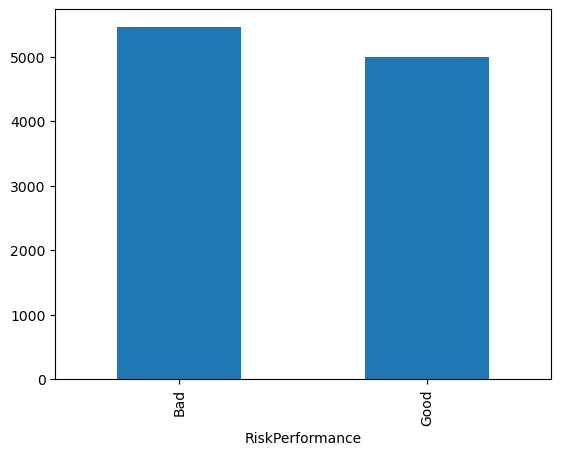

In [8]:
df["RiskPerformance"].value_counts().plot(kind="bar")

### Observation

The target variable is relatively balanced, with approximately 52% "Bad" and 48% "Good" applications.

Although class imbalance is not severe, model performance will still be evaluated using Precision, Recall, F1-score, and ROC-AUC rather than relying solely on Accuracy.

In [9]:
df.isna().sum()

RiskPerformance                       0
ExternalRiskEstimate                  0
MSinceOldestTradeOpen                 0
MSinceMostRecentTradeOpen             0
AverageMInFile                        0
NumSatisfactoryTrades                 0
NumTrades60Ever2DerogPubRec           0
NumTrades90Ever2DerogPubRec           0
PercentTradesNeverDelq                0
MSinceMostRecentDelq                  0
MaxDelq2PublicRecLast12M              0
MaxDelqEver                           0
NumTotalTrades                        0
NumTradesOpeninLast12M                0
PercentInstallTrades                  0
MSinceMostRecentInqexcl7days          0
NumInqLast6M                          0
NumInqLast6Mexcl7days                 0
NetFractionRevolvingBurden            0
NetFractionInstallBurden              0
NumRevolvingTradesWBalance            0
NumInstallTradesWBalance              0
NumBank2NatlTradesWHighUtilization    0
PercentTradesWBalance                 0
dtype: int64

In [10]:
(df == -7).sum()

RiskPerformance                          0
ExternalRiskEstimate                     0
MSinceOldestTradeOpen                    0
MSinceMostRecentTradeOpen                0
AverageMInFile                           0
NumSatisfactoryTrades                    0
NumTrades60Ever2DerogPubRec              0
NumTrades90Ever2DerogPubRec              0
PercentTradesNeverDelq                   0
MSinceMostRecentDelq                  4664
MaxDelq2PublicRecLast12M                 0
MaxDelqEver                              0
NumTotalTrades                           0
NumTradesOpeninLast12M                   0
PercentInstallTrades                     0
MSinceMostRecentInqexcl7days          1855
NumInqLast6M                             0
NumInqLast6Mexcl7days                    0
NetFractionRevolvingBurden               0
NetFractionInstallBurden                 0
NumRevolvingTradesWBalance               0
NumInstallTradesWBalance                 0
NumBank2NatlTradesWHighUtilization       0
PercentTrad

In [11]:
(df == -8).sum()

RiskPerformance                          0
ExternalRiskEstimate                     0
MSinceOldestTradeOpen                  239
MSinceMostRecentTradeOpen                0
AverageMInFile                           0
NumSatisfactoryTrades                    0
NumTrades60Ever2DerogPubRec              0
NumTrades90Ever2DerogPubRec              0
PercentTradesNeverDelq                   0
MSinceMostRecentDelq                   176
MaxDelq2PublicRecLast12M                 0
MaxDelqEver                              0
NumTotalTrades                           0
NumTradesOpeninLast12M                   0
PercentInstallTrades                     0
MSinceMostRecentInqexcl7days           476
NumInqLast6M                             0
NumInqLast6Mexcl7days                    0
NetFractionRevolvingBurden             186
NetFractionInstallBurden              3419
NumRevolvingTradesWBalance             156
NumInstallTradesWBalance               861
NumBank2NatlTradesWHighUtilization     583
PercentTrad

In [12]:
(df == -9).sum()

RiskPerformance                         0
ExternalRiskEstimate                  598
MSinceOldestTradeOpen                 588
MSinceMostRecentTradeOpen             588
AverageMInFile                        588
NumSatisfactoryTrades                 588
NumTrades60Ever2DerogPubRec           588
NumTrades90Ever2DerogPubRec           588
PercentTradesNeverDelq                588
MSinceMostRecentDelq                  588
MaxDelq2PublicRecLast12M              588
MaxDelqEver                           588
NumTotalTrades                        588
NumTradesOpeninLast12M                588
PercentInstallTrades                  588
MSinceMostRecentInqexcl7days          588
NumInqLast6M                          588
NumInqLast6Mexcl7days                 588
NetFractionRevolvingBurden            588
NetFractionInstallBurden              588
NumRevolvingTradesWBalance            588
NumInstallTradesWBalance              588
NumBank2NatlTradesWHighUtilization    588
PercentTradesWBalance             

In [13]:
special_values = pd.DataFrame({
    "-7": (df == -7).sum(),
    "-8": (df == -8).sum(),
    "-9": (df == -9).sum()
})

special_values

,-7,-8,-9
RiskPerformance,0,0,0
ExternalRiskEstimate,0,0,598
MSinceOldestTradeOpen,0,239,588
MSinceMostRecentTradeOpen,0,0,588
AverageMInFile,0,0,588
NumSatisfactoryTrades,0,0,588
NumTrades60Ever2DerogPubRec,0,0,588
NumTrades90Ever2DerogPubRec,0,0,588
PercentTradesNeverDelq,0,0,588
MSinceMostRecentDelq,4664,176,588


In [14]:
special_values.sort_values("-9", ascending=False)

,-7,-8,-9
ExternalRiskEstimate,0,0,598
NumTotalTrades,0,0,588
NumBank2NatlTradesWHighUtilization,0,583,588
NumInstallTradesWBalance,0,861,588
NumRevolvingTradesWBalance,0,156,588
NetFractionInstallBurden,0,3419,588
NetFractionRevolvingBurden,0,186,588
NumInqLast6Mexcl7days,0,0,588
NumInqLast6M,0,0,588
MSinceMostRecentInqexcl7days,1855,476,588


## Key Findings

- The dataset contains approximately 10,000 historical HELOC applications.
- The prediction task is binary classification.
- The dataset contains multiple special values (-7, -8, -9), requiring careful preprocessing.
- Several financial attributes may strongly influence lending decisions.
- Class imbalance should be considered during model development.

# 2. Exploratory Data Analysis

The objective of this section is to understand the distribution of applicant characteristics, identify abnormal values, and explore potential relationships between financial variables and credit risk.

In [15]:
numeric_cols = df.select_dtypes(include="number").columns

print(f"Number of numerical features: {len(numeric_cols)}")
numeric_cols

Number of numerical features: 23


Index(['ExternalRiskEstimate', 'MSinceOldestTradeOpen',
       'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades',
       'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec',
       'PercentTradesNeverDelq', 'MSinceMostRecentDelq',
       'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades',
       'NumTradesOpeninLast12M', 'PercentInstallTrades',
       'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NumInqLast6Mexcl7days',
       'NetFractionRevolvingBurden', 'NetFractionInstallBurden',
       'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance',
       'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance'],
      dtype='object')

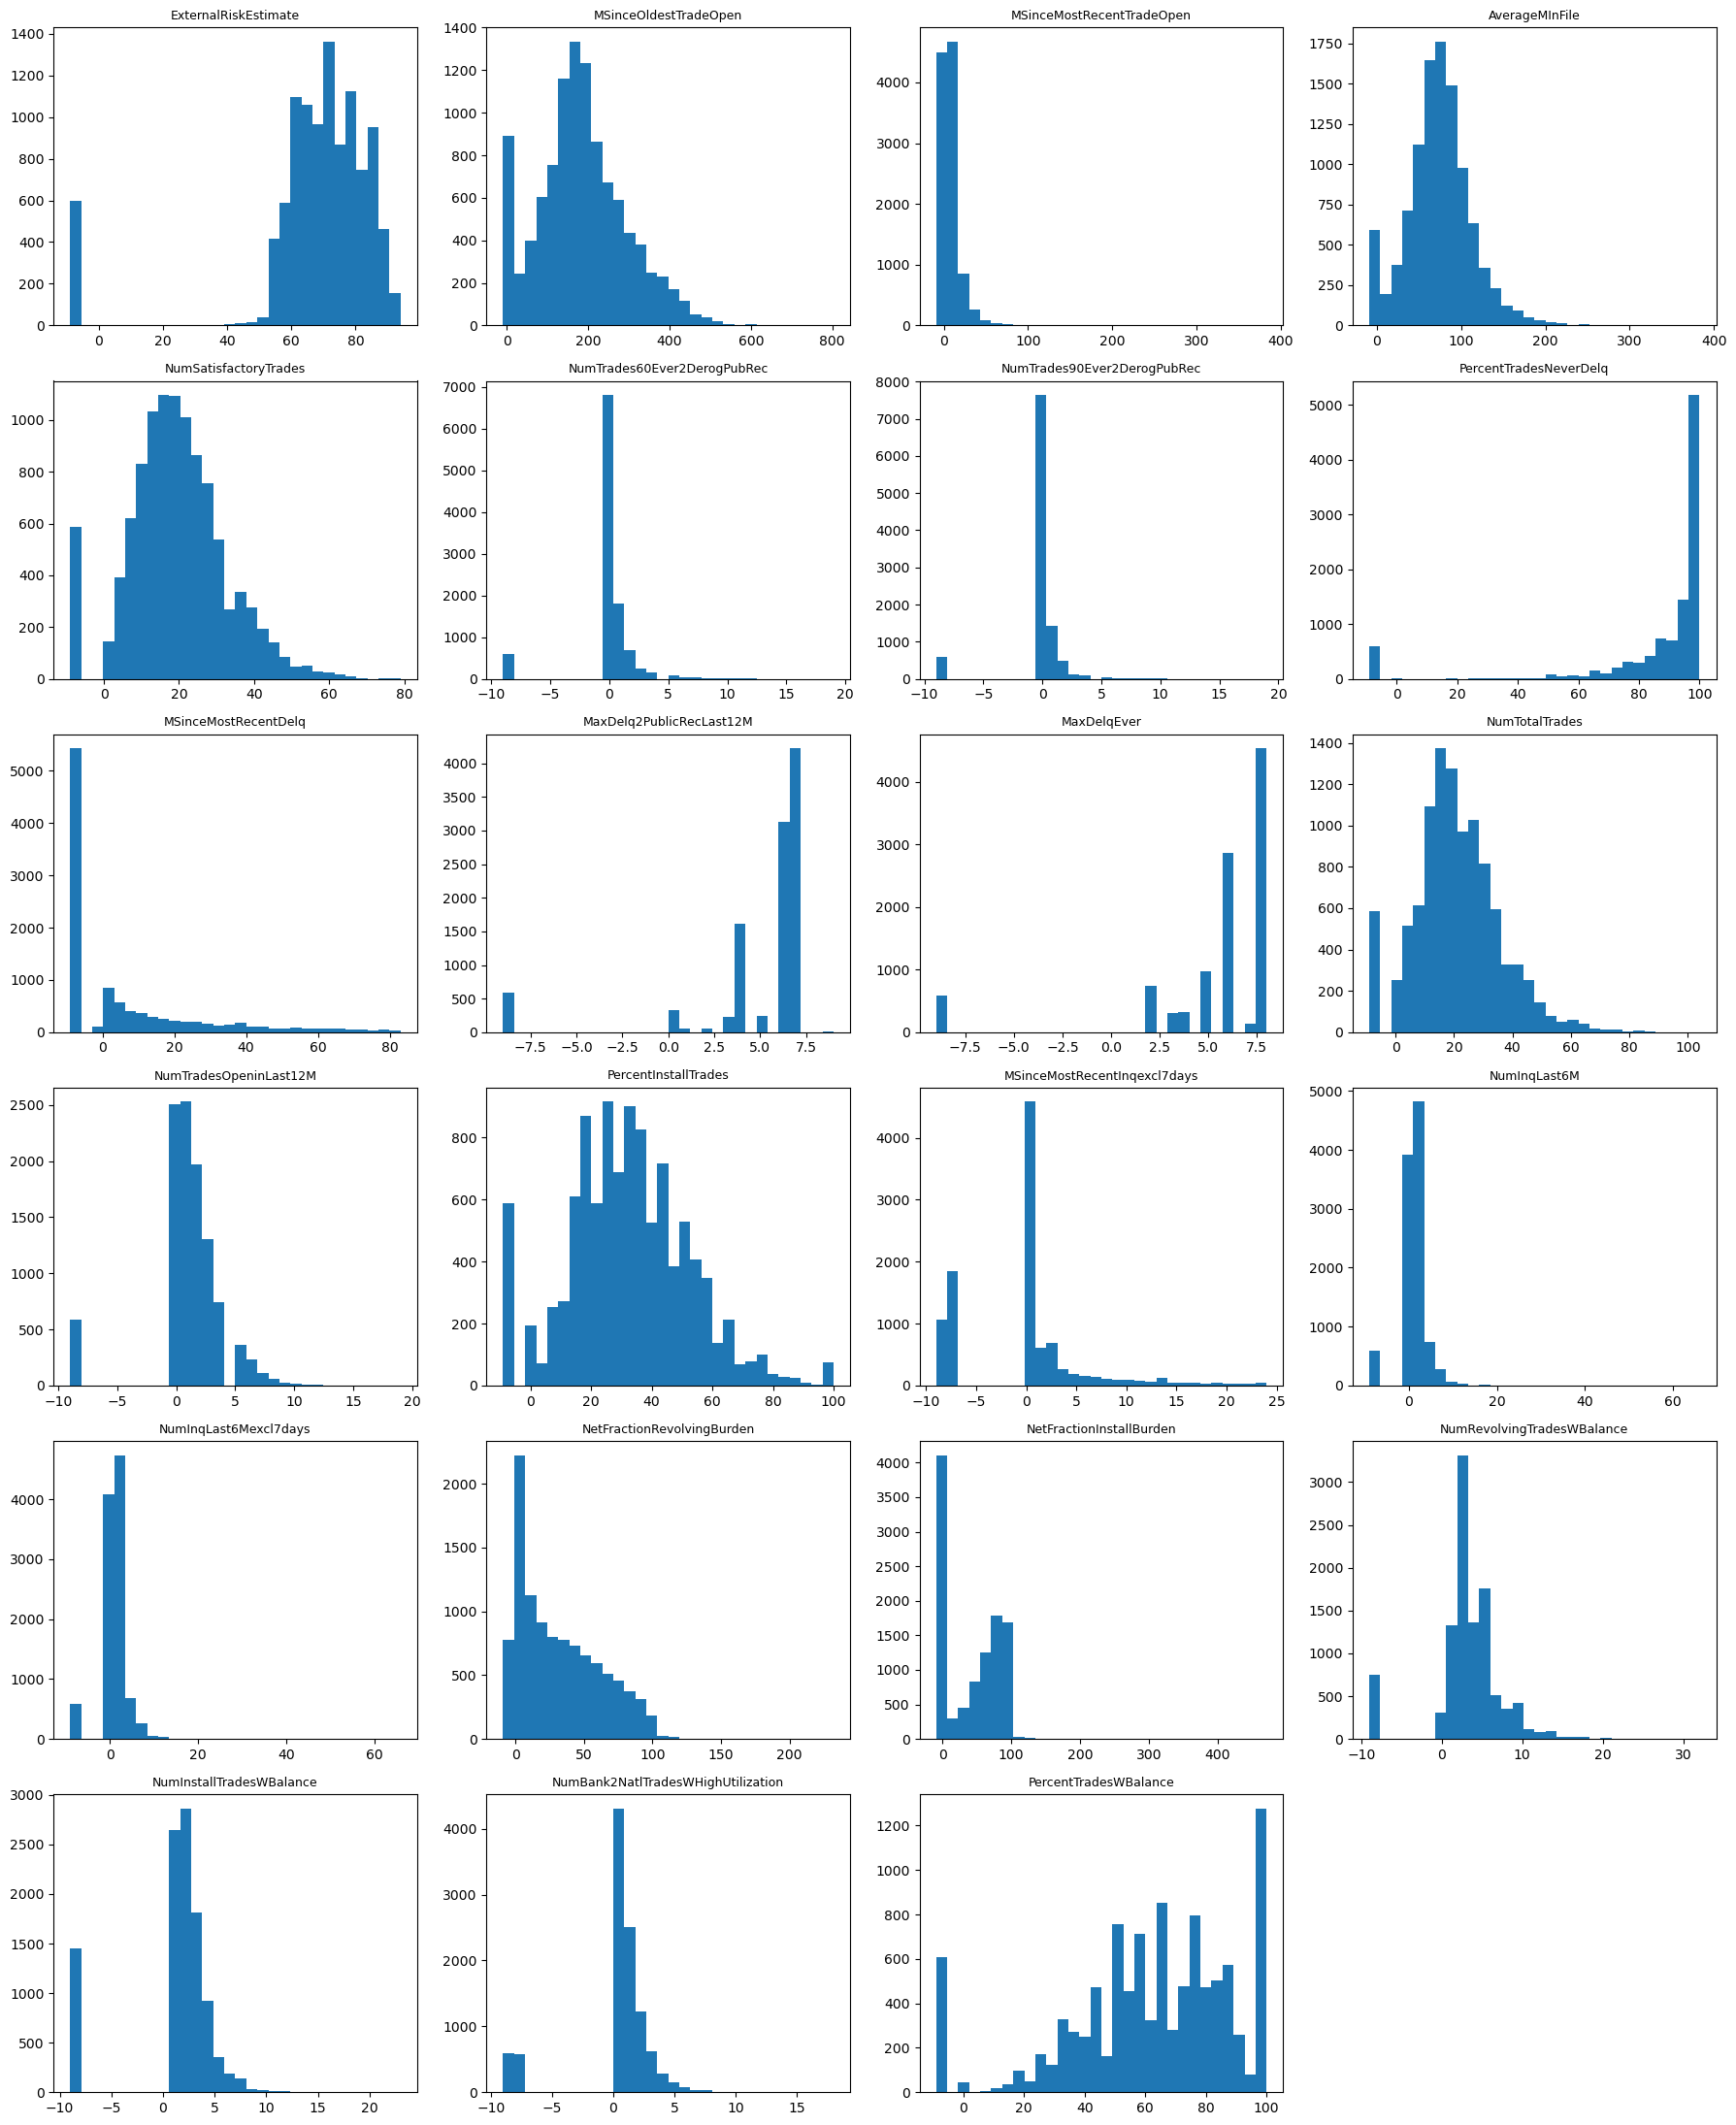

In [16]:
fig, axes = plt.subplots(6, 4, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Observation

Most financial variables exhibit right-skewed distributions rather than normal distributions.

Several variables contain large spikes at the special values (-7, -8, and -9), suggesting that these values represent business-specific codes instead of ordinary numerical measurements.

These variables require careful preprocessing before model training.

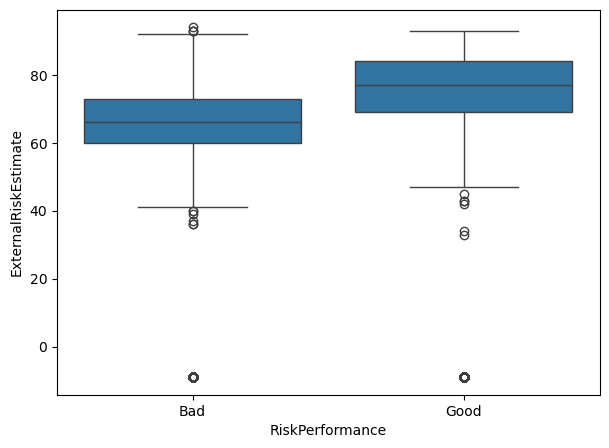

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="RiskPerformance",
    y="ExternalRiskEstimate"
)

plt.show()

<Axes: xlabel='RiskPerformance', ylabel='PercentTradesNeverDelq'>

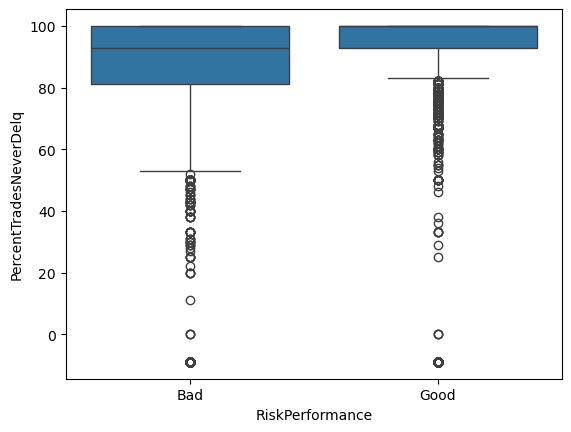

In [18]:
sns.boxplot(
    data=df,
    x="RiskPerformance",
    y="PercentTradesNeverDelq"
)

<Axes: xlabel='RiskPerformance', ylabel='MSinceMostRecentDelq'>

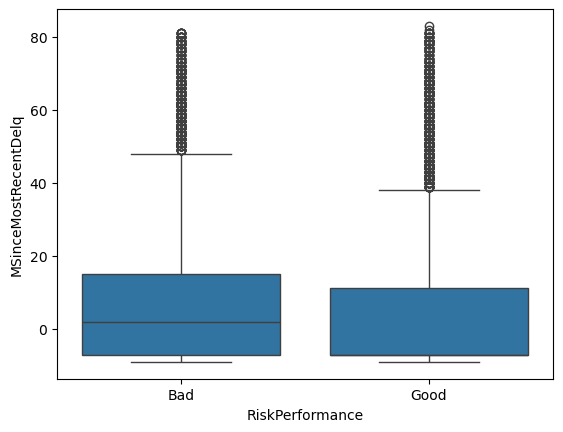

In [19]:
sns.boxplot(
    data=df,
    x="RiskPerformance",
    y="MSinceMostRecentDelq"
)

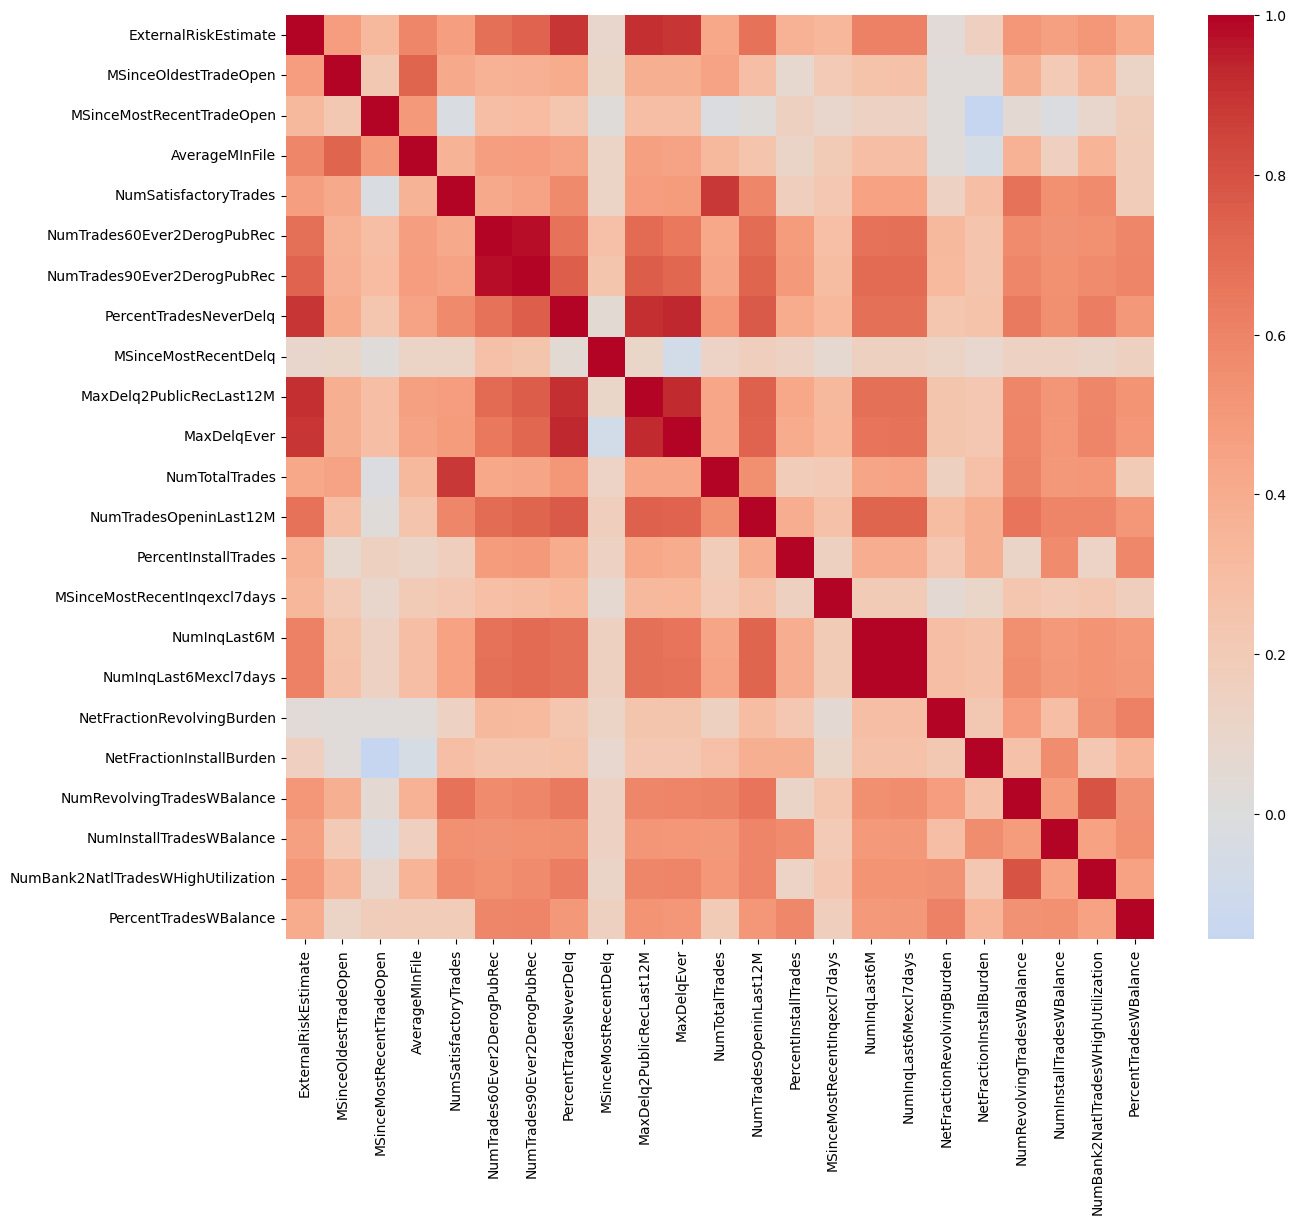

In [20]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

In [21]:
corr = df[numeric_cols].corr()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr.head(20)

NumInqLast6M                 NumInqLast6Mexcl7days                 0.996683
NumTrades60Ever2DerogPubRec  NumTrades90Ever2DerogPubRec           0.975480
PercentTradesNeverDelq       MaxDelqEver                           0.928059
MaxDelq2PublicRecLast12M     MaxDelqEver                           0.924642
ExternalRiskEstimate         MaxDelq2PublicRecLast12M              0.908919
PercentTradesNeverDelq       MaxDelq2PublicRecLast12M              0.907249
ExternalRiskEstimate         PercentTradesNeverDelq                0.895690
                             MaxDelqEver                           0.890247
NumSatisfactoryTrades        NumTotalTrades                        0.886282
NumRevolvingTradesWBalance   NumBank2NatlTradesWHighUtilization    0.791191
PercentTradesNeverDelq       NumTradesOpeninLast12M                0.771269
NumTrades90Ever2DerogPubRec  MaxDelq2PublicRecLast12M              0.762342
                             PercentTradesNeverDelq                0.751725
MaxDelq2Publ

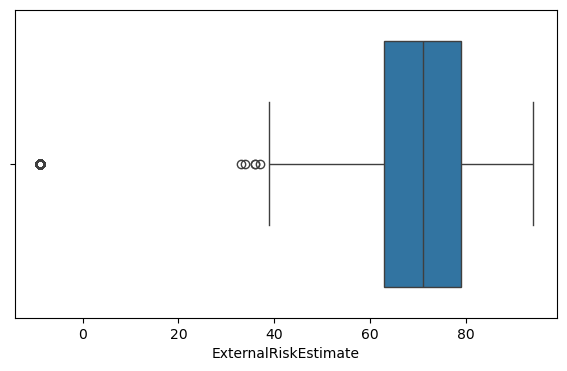

In [22]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df["ExternalRiskEstimate"])

plt.show()

<Axes: xlabel='NetFractionRevolvingBurden'>

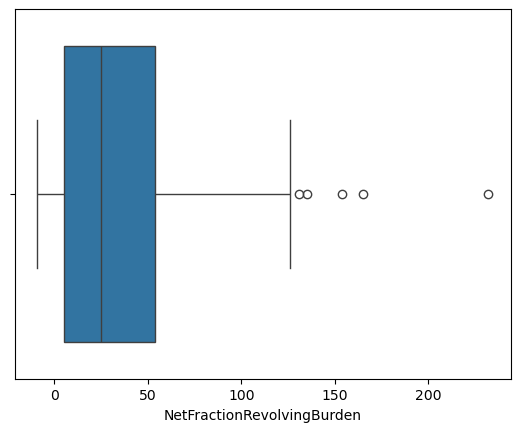

In [23]:
sns.boxplot(x=df["NetFractionRevolvingBurden"])

In [24]:
special_values = pd.DataFrame({
    "-7": (df == -7).sum(),
    "-8": (df == -8).sum(),
    "-9": (df == -9).sum()
})

special_values.sort_values("-9", ascending=False)

,-7,-8,-9
ExternalRiskEstimate,0,0,598
NumTotalTrades,0,0,588
NumBank2NatlTradesWHighUtilization,0,583,588
NumInstallTradesWBalance,0,861,588
NumRevolvingTradesWBalance,0,156,588
NetFractionInstallBurden,0,3419,588
NetFractionRevolvingBurden,0,186,588
NumInqLast6Mexcl7days,0,0,588
NumInqLast6M,0,0,588
MSinceMostRecentInqexcl7days,1855,476,588


In [25]:
special_values.sort_values("-7", ascending=False)

,-7,-8,-9
MSinceMostRecentDelq,4664,176,588
MSinceMostRecentInqexcl7days,1855,476,588
RiskPerformance,0,0,0
NumTradesOpeninLast12M,0,0,588
NumBank2NatlTradesWHighUtilization,0,583,588
NumInstallTradesWBalance,0,861,588
NumRevolvingTradesWBalance,0,156,588
NetFractionInstallBurden,0,3419,588
NetFractionRevolvingBurden,0,186,588
NumInqLast6Mexcl7days,0,0,588


In [26]:
special_values.sort_values("-8", ascending=False)

,-7,-8,-9
NetFractionInstallBurden,0,3419,588
NumInstallTradesWBalance,0,861,588
NumBank2NatlTradesWHighUtilization,0,583,588
MSinceMostRecentInqexcl7days,1855,476,588
MSinceOldestTradeOpen,0,239,588
NetFractionRevolvingBurden,0,186,588
MSinceMostRecentDelq,4664,176,588
NumRevolvingTradesWBalance,0,156,588
PercentTradesWBalance,0,18,588
NumTradesOpeninLast12M,0,0,588


## Business Interpretation

The exploratory analysis revealed several important business insights.

1. ExternalRiskEstimate clearly differentiates good and bad applicants, indicating that credit score is one of the strongest predictors of loan performance.

2. Applicants with higher PercentTradesNeverDelq generally exhibit lower credit risk, suggesting that repayment history is highly informative.

3. Several variables contain special coded values (-7, -8, -9), which represent business conditions rather than ordinary missing values. These values require feature-specific preprocessing instead of standard imputation.

4. Most numerical variables exhibit right-skewed distributions, making tree-based models more appropriate than models relying on strong normality assumptions.

# 3. Data Preprocessing

After exploring the dataset, the next step is to prepare the data for machine learning. This section includes:

- Removing no-bureau-record rows (all features = -9)
- Encoding the target variable (**Bad = 1**, i.e. default is the positive class)
- Splitting the dataset with stratified sampling
- Defining a business-aware special-value transformation
- Removing one redundant, highly correlated feature

To avoid data leakage, every learned statistic (special-value fill values, imputation medians, scaling parameters) is fitted **only on the training data**. Imputation and scaling are performed inside sklearn `Pipeline`s in Section 4, so the exact same transformations are guaranteed at deployment time.

The special-value logic lives in `src/preprocessing.py` and is **imported by both this notebook and the Streamlit app** — a single source of truth that prevents train/serve skew.

In [27]:
import sys
sys.path.append("..")

from src.preprocessing import drop_no_record_rows, SpecialValueTransformer

In [28]:
df_model = df.copy()

## 3.1 Remove No-Bureau-Record Rows

The FICO dataset contains a block of rows in which **every** feature equals -9, meaning no credit bureau record was found for the applicant. These rows carry no usable information for a bureau-data model and are conventionally removed in published work on this dataset.

In [29]:
df_model = drop_no_record_rows(df_model)
df_model.shape

Dropped 588 rows with no bureau record (5.6% of the data)


(9871, 24)

## 3.2 Encode Target Variable

The positive class is defined as **default (Bad = 1)**, following credit-risk convention. With this encoding:

- `predict_proba(X)[:, 1]` is directly the **probability of default (PD)** shown in the application,
- **Recall** answers the business question "what share of true defaulters does the model catch",
- **Precision** answers "of the applicants we flag as risky, how many actually default".

In [30]:
df_model["RiskPerformance"] = df_model["RiskPerformance"].map({
    "Bad": 1,   # default = positive class
    "Good": 0
})

df_model["RiskPerformance"].value_counts(normalize=True)

RiskPerformance
1    0.520312
0    0.479688
Name: proportion, dtype: float64

## 3.3 Separate Features and Target

In [31]:
X = df_model.drop(columns=["RiskPerformance"])
y = df_model["RiskPerformance"]

print(X.shape)
print(y.shape)

(9871, 23)
(9871,)


## 3.4 Train-Test Split

The dataset is split **before** any learned preprocessing to prevent data leakage. Stratified sampling preserves the class distribution in both sets.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7896, 23)
(1975, 23)


## 3.5 Business-Aware Special-Value Handling

The three special codes have **different meanings**, so a single blanket rule (e.g. median imputation for everything) would destroy information:

- **-7 (Condition Not Met)** — on `MSinceMostRecentDelq` and `MSinceMostRecentInqexcl7days` this means the event **never happened** (never delinquent / no recent inquiry). That is a *low-risk* signal. Median-filling would wrongly turn the safest applicants into "average" ones. Instead, these values are filled with the **maximum valid value observed in the training set** (event infinitely long ago) and an indicator column `<col>_NeverHappened` is added.
- **-8 / -9 (information missing)** — converted to `NaN` for the downstream median imputer, with a `<col>_WasSpecial` indicator so the model can still learn from the *fact* that information was missing.

The logic is implemented as a sklearn-compatible `SpecialValueTransformer` (see `src/preprocessing.py`) and placed as the **first step of every model pipeline** in Section 4, so the saved pipeline accepts raw feature values end-to-end. Below is a quick demonstration of its effect on the training data.

In [33]:
svt_demo = SpecialValueTransformer().fit(X_train)
X_demo = svt_demo.transform(X_train)

print("Columns before:", X_train.shape[1])
print("Columns after :", X_demo.shape[1])
print()
print("Learned -7 fill values (train max):", svt_demo.never_fill_)
print()
indicator_cols = [c for c in X_demo.columns if c.endswith(("_NeverHappened", "_WasSpecial"))]
X_demo[indicator_cols].sum().sort_values(ascending=False).head(10)

Columns before: 23
Columns after : 35

Learned -7 fill values (train max): {'MSinceMostRecentDelq': 83.0, 'MSinceMostRecentInqexcl7days': 24.0}



MSinceMostRecentDelq_NeverHappened               3735
NetFractionInstallBurden_WasSpecial              2735
MSinceMostRecentInqexcl7days_NeverHappened       1497
NumInstallTradesWBalance_WasSpecial               709
NumBank2NatlTradesWHighUtilization_WasSpecial     477
MSinceMostRecentInqexcl7days_WasSpecial           378
MSinceOldestTradeOpen_WasSpecial                  186
NetFractionRevolvingBurden_WasSpecial             163
NumRevolvingTradesWBalance_WasSpecial             135
MSinceMostRecentDelq_WasSpecial                   132
dtype: int64

## 3.6 Remove a Redundant Feature

The EDA correlation analysis showed that `NumInqLast6M` and `NumInqLast6Mexcl7days` are almost perfectly correlated — they capture the same recent-inquiry behaviour. Keeping both inflates their apparent importance and destabilizes logistic regression coefficients (multicollinearity), so the near-duplicate is dropped. This also simplifies the application's input form by one field.

In [34]:
print("Correlation:",
      X_train["NumInqLast6M"].corr(X_train["NumInqLast6Mexcl7days"]).round(4))

X_train = X_train.drop(columns=["NumInqLast6Mexcl7days"])
X_test = X_test.drop(columns=["NumInqLast6Mexcl7days"])

X_train.shape

Correlation: 0.9922


(7896, 22)

### Preprocessing Summary

1. Removed no-bureau-record rows (all features = -9).
2. Encoded the target with **default as the positive class** (Bad = 1).
3. Split the dataset with stratified sampling **before** any learned preprocessing.
4. Defined a business-aware `SpecialValueTransformer` (indicator flags + semantic fill for -7), applied inside the model pipelines.
5. Dropped one near-duplicate inquiry feature to reduce multicollinearity.

Median imputation and (for linear models) standardization happen inside the pipelines in the next section, fitted on training folds only.

# 4. Baseline Model Development

This section develops four baseline classifiers — Logistic Regression, Decision Tree, Random Forest, and XGBoost — to predict the **probability of default**.

Every model is wrapped in a sklearn `Pipeline` whose first steps handle special values and imputation (plus standardization for Logistic Regression). This guarantees that:

- all preprocessing statistics are learned only from training data (no leakage, also inside cross-validation),
- the saved artifact accepts **raw feature values** end-to-end, so the Streamlit app cannot drift from the training-time preprocessing,
- Logistic Regression coefficients are computed on **standardized features** and are therefore directly comparable in Section 6.

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [36]:
results = {}  # auto-collected metrics for the Section 5 comparison table

def evaluate_model(model, X_test, y_test, name=None):
    """Evaluate a fitted model/pipeline. Positive class = default (Bad = 1)."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]   # probability of default

    metrics = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
    }

    for k, v in metrics.items():
        print(f"{k:9s}: {v:.4f}")
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    if name is not None:
        results[name] = metrics
    return metrics

## 4.1 Logistic Regression

Logistic Regression is the primary candidate because it is intrinsically interpretable — with standardized inputs, its coefficients provide transparent, regulator-friendly explanations for each decision, which matters in credit-risk applications. The pipeline: special-value handling → median imputation → standardization → logistic regression.

In [37]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("special", SpecialValueTransformer()),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=1000, random_state=42)),
])

pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('special', SpecialValueTransformer()),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [38]:
evaluate_model(pipe_lr, X_test, y_test, name="Logistic Regression")

Accuracy : 0.7362
Precision: 0.7380
Recall   : 0.7646
F1 Score : 0.7511
ROC-AUC  : 0.8081

Classification Report

              precision    recall  f1-score   support

           0       0.73      0.71      0.72       947
           1       0.74      0.76      0.75      1028

    accuracy                           0.74      1975
   macro avg       0.74      0.73      0.74      1975
weighted avg       0.74      0.74      0.74      1975



{'Accuracy': 0.7362025316455696,
 'Precision': 0.7380281690140845,
 'Recall': 0.7645914396887159,
 'F1 Score': 0.7510750119445772,
 'ROC-AUC': 0.8081202568832972}

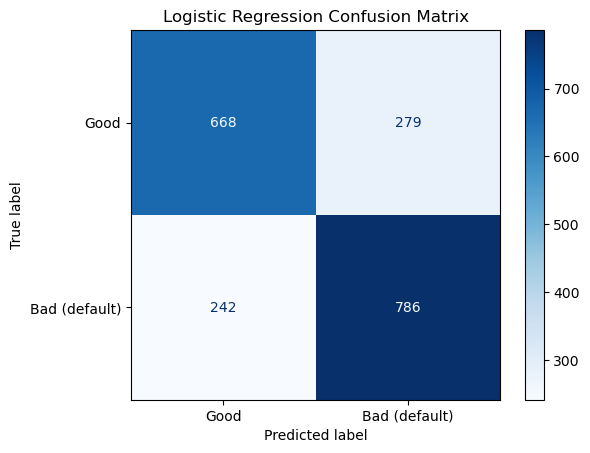

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    pipe_lr,
    X_test,
    y_test,
    display_labels=["Good", "Bad (default)"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.savefig("../images/logistic_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

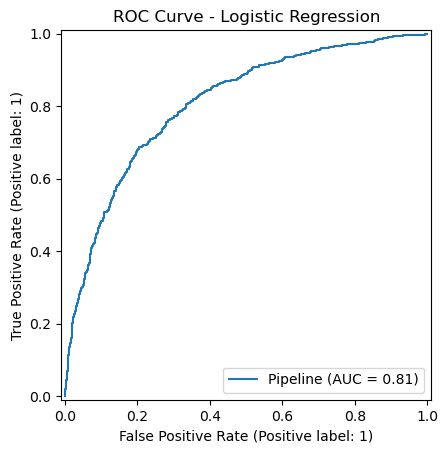

In [40]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    pipe_lr,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.savefig("../images/logistic_roc.png", dpi=300, bbox_inches="tight")
plt.show()

### Results Interpretation

Logistic Regression achieved an accuracy of **73.6%** and a ROC-AUC of **0.808** on the hold-out test set.

Because the positive class is default, the recall of **0.765** means the model catches roughly 76% of true defaulters at the default 0.5 threshold, while 242 defaulters were missed (false negatives) — the costly error type in lending. The threshold analysis in Section 7 addresses this trade-off explicitly instead of relying on the 0.5 default.

## 4.2 Decision Tree

A single decision tree captures nonlinear relationships and feature interactions without linear assumptions, but an unconstrained tree tends to overfit. It is included as a benchmark for the ensemble methods.

In [41]:
from sklearn.tree import DecisionTreeClassifier

pipe_tree = Pipeline([
    ("special", SpecialValueTransformer()),
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   DecisionTreeClassifier(random_state=42)),
])

pipe_tree.fit(X_train, y_train)

Pipeline(steps=[('special', SpecialValueTransformer()),
                ('imputer', SimpleImputer(strategy='median')),
                ('model', DecisionTreeClassifier(random_state=42))])

In [42]:
evaluate_model(pipe_tree, X_test, y_test, name="Decision Tree")

Accuracy : 0.6390
Precision: 0.6516
Recall   : 0.6586
F1 Score : 0.6551
ROC-AUC  : 0.6382

Classification Report

              precision    recall  f1-score   support

           0       0.62      0.62      0.62       947
           1       0.65      0.66      0.66      1028

    accuracy                           0.64      1975
   macro avg       0.64      0.64      0.64      1975
weighted avg       0.64      0.64      0.64      1975



{'Accuracy': 0.6389873417721519,
 'Precision': 0.6515880654475458,
 'Recall': 0.6585603112840467,
 'F1 Score': 0.6550556361877117,
 'ROC-AUC': 0.6381502717983064}

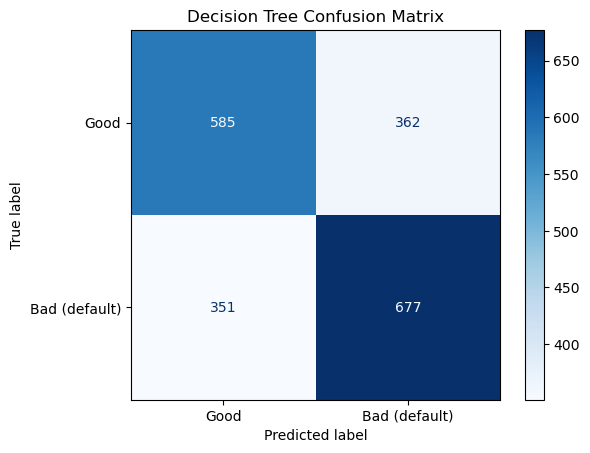

In [43]:
ConfusionMatrixDisplay.from_estimator(
    pipe_tree, X_test, y_test,
    display_labels=["Good", "Bad (default)"], cmap="Blues"
)
plt.title("Decision Tree Confusion Matrix")
plt.show()

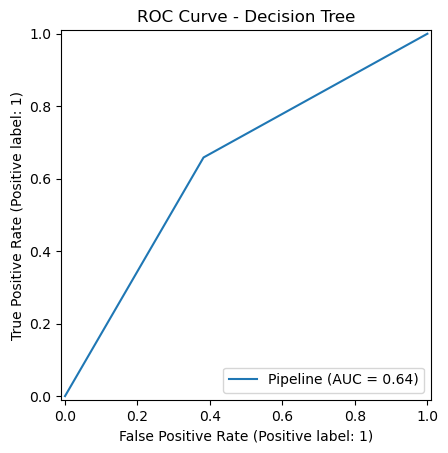

In [44]:
RocCurveDisplay.from_estimator(pipe_tree, X_test, y_test)
plt.title("ROC Curve - Decision Tree")
plt.show()

### Results Interpretation

As expected, the unconstrained Decision Tree performed substantially worse (accuracy 63.9%, ROC-AUC **0.638**) — it memorizes training data and generalizes poorly, which is also visible in its nearly piecewise-linear ROC curve. It serves as a useful lower benchmark before evaluating ensemble methods.

## 4.3 Random Forest

Random Forest averages many decorrelated trees (bagging), which reduces the variance that hurts the single tree while still capturing nonlinear structure.

In [45]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("special", SpecialValueTransformer()),
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(random_state=42)),
])

pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('special', SpecialValueTransformer()),
                ('imputer', SimpleImputer(strategy='median')),
                ('model', RandomForestClassifier(random_state=42))])

In [46]:
evaluate_model(pipe_rf, X_test, y_test, name="Random Forest")

Accuracy : 0.7367
Precision: 0.7356
Recall   : 0.7714
F1 Score : 0.7531
ROC-AUC  : 0.8017

Classification Report

              precision    recall  f1-score   support

           0       0.74      0.70      0.72       947
           1       0.74      0.77      0.75      1028

    accuracy                           0.74      1975
   macro avg       0.74      0.74      0.74      1975
weighted avg       0.74      0.74      0.74      1975



{'Accuracy': 0.7367088607594937,
 'Precision': 0.735621521335807,
 'Recall': 0.7714007782101168,
 'F1 Score': 0.7530864197530864,
 'ROC-AUC': 0.8016586270795755}

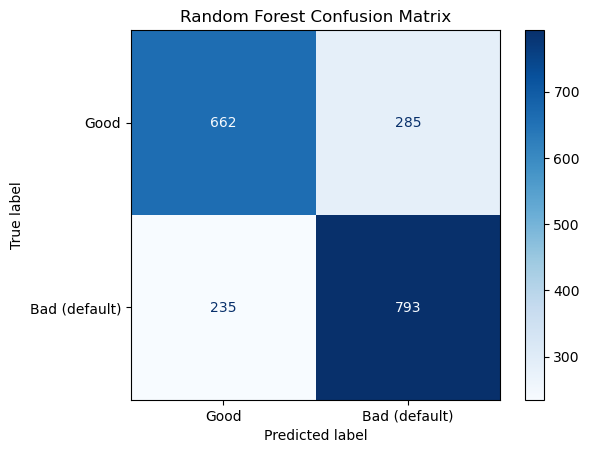

In [47]:
ConfusionMatrixDisplay.from_estimator(
    pipe_rf, X_test, y_test,
    display_labels=["Good", "Bad (default)"], cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.show()

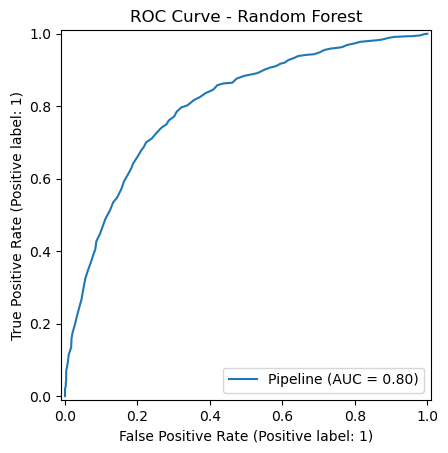

In [48]:
RocCurveDisplay.from_estimator(pipe_rf, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

### Results Interpretation

Random Forest recovered most of the single tree's lost performance through variance reduction, reaching a ROC-AUC of **0.802** — close to, but still below, Logistic Regression (0.808). Its recall of **0.771** is slightly higher than Logistic Regression's at the 0.5 threshold, but whether any of these differences are meaningful is checked with cross-validation in Section 5.

## 4.4 XGBoost

XGBoost builds trees sequentially, each correcting the errors of the previous ones (boosting with regularization). It is widely used in credit-risk modeling, but typically requires hyperparameter tuning to reach its potential — the default configuration here is a baseline, and a small tuning pass follows in Section 5.3.

In [49]:
%pip install xgboost --timeout 1000

Note: you may need to restart the kernel to use updated packages.


In [50]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ("special", SpecialValueTransformer()),
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(random_state=42, eval_metric="logloss")),
])

pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('special', SpecialValueTransformer()),
                ('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weigh...ne,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [51]:
evaluate_model(pipe_xgb, X_test, y_test, name="XGBoost")

Accuracy : 0.7195
Precision: 0.7182
Recall   : 0.7588
F1 Score : 0.7379
ROC-AUC  : 0.7803

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.68      0.70       947
           1       0.72      0.76      0.74      1028

    accuracy                           0.72      1975
   macro avg       0.72      0.72      0.72      1975
weighted avg       0.72      0.72      0.72      1975



{'Accuracy': 0.719493670886076,
 'Precision': 0.7182320441988951,
 'Recall': 0.7587548638132295,
 'F1 Score': 0.7379375591296121,
 'ROC-AUC': 0.780319994740713}

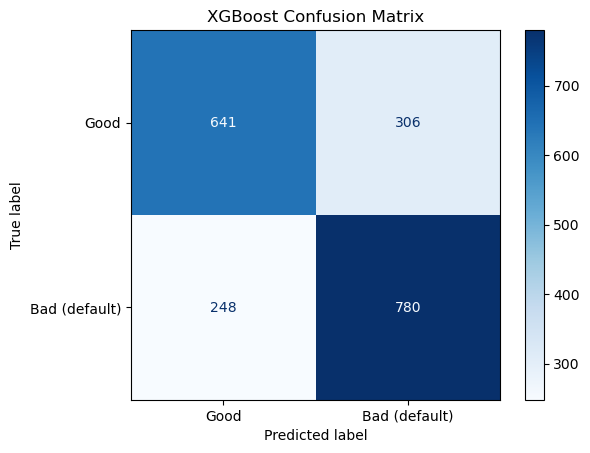

In [52]:
ConfusionMatrixDisplay.from_estimator(
    pipe_xgb, X_test, y_test,
    display_labels=["Good", "Bad (default)"], cmap="Blues"
)
plt.title("XGBoost Confusion Matrix")
plt.show()

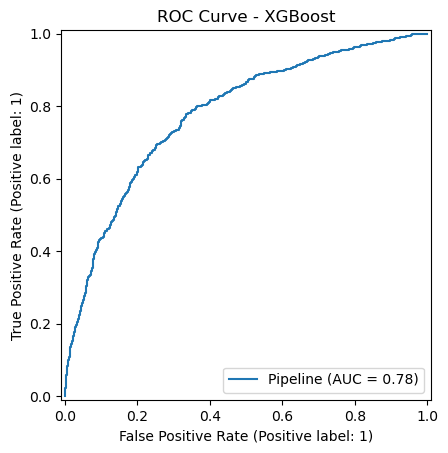

In [53]:
RocCurveDisplay.from_estimator(pipe_xgb, X_test, y_test)
plt.title("ROC Curve - XGBoost")
plt.show()

### Results Interpretation

With default hyperparameters XGBoost reached a ROC-AUC of **0.780**, trailing both Logistic Regression and Random Forest — boosting typically needs tuning to reach its potential. Section 5.3 runs a small grid search to check how much tuning closes the gap.

# 5. Model Comparison

## 5.1 Test-Set Comparison

The metrics below are collected automatically from `evaluate_model` (no hand-copied numbers).

In [54]:
comparison = pd.DataFrame(results).T.round(4)
comparison.sort_values(by="ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7362,0.7380,0.7646,0.7511,0.8081
Random Forest,0.7367,0.7356,0.7714,0.7531,0.8017
XGBoost,0.7195,0.7182,0.7588,0.7379,0.7803
Decision Tree,0.6390,0.6516,0.6586,0.6551,0.6382


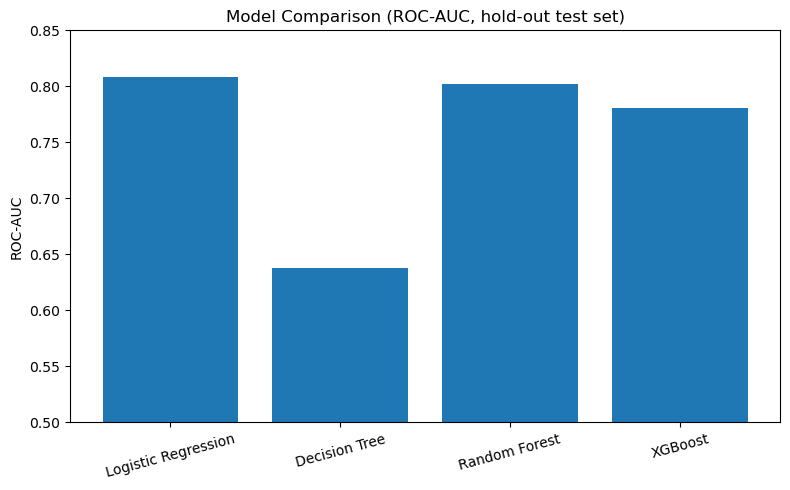

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(comparison.index, comparison["ROC-AUC"])
plt.title("Model Comparison (ROC-AUC, hold-out test set)")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 0.85)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.2 Cross-Validated Comparison

A single 80/20 split can rank two similar models differently by chance. 5-fold stratified cross-validation on the training set estimates both the mean ROC-AUC and its variability, so we can judge whether differences between models are meaningful. Because preprocessing lives inside each pipeline, it is re-fitted on every fold — no leakage.

In [56]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, pipe in [
    ("Logistic Regression", pipe_lr),
    ("Decision Tree",       pipe_tree),
    ("Random Forest",       pipe_rf),
    ("XGBoost",             pipe_xgb),
]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_rows.append({"Model": name,
                    "CV ROC-AUC (mean)": scores.mean(),
                    "CV ROC-AUC (std)": scores.std()})
    print(f"{name:20s}: {scores.mean():.4f} ± {scores.std():.4f}")

cv_comparison = pd.DataFrame(cv_rows).round(4)
cv_comparison

Logistic Regression : 0.8041 ± 0.0094
Decision Tree       : 0.6292 ± 0.0102
Random Forest       : 0.7911 ± 0.0125
XGBoost             : 0.7786 ± 0.0074


,Model,CV ROC-AUC (mean),CV ROC-AUC (std)
0,Logistic Regression,0.8041,0.0094
1,Decision Tree,0.6292,0.0102
2,Random Forest,0.7911,0.0125
3,XGBoost,0.7786,0.0074


## 5.3 XGBoost Tuning (small grid)

A compact grid search over the parameters that matter most for boosting, to verify whether a tuned XGBoost overtakes the simpler models.

In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth":     [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators":  [200, 400],
}

grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)

grid_xgb.fit(X_train, y_train)

print("Best params :", grid_xgb.best_params_)
print(f"Best CV AUC : {grid_xgb.best_score_:.4f}")

Best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV AUC : 0.8033


In [58]:
evaluate_model(grid_xgb.best_estimator_, X_test, y_test, name="XGBoost (tuned)")

Accuracy : 0.7362
Precision: 0.7363
Recall   : 0.7685
F1 Score : 0.7520
ROC-AUC  : 0.8048

Classification Report

              precision    recall  f1-score   support

           0       0.74      0.70      0.72       947
           1       0.74      0.77      0.75      1028

    accuracy                           0.74      1975
   macro avg       0.74      0.73      0.74      1975
weighted avg       0.74      0.74      0.74      1975



{'Accuracy': 0.7362025316455696,
 'Precision': 0.7362534948741846,
 'Recall': 0.7684824902723736,
 'F1 Score': 0.752022846263684,
 'ROC-AUC': 0.8047818423117854}

### Results Interpretation

The grid search selected a shallow, conservative configuration (max_depth = 3, learning_rate = 0.05, n_estimators = 200), lifting XGBoost's CV ROC-AUC from 0.7786 to **0.8033** — essentially closing the gap with Logistic Regression (0.8041 ± 0.0094). The difference between the two is far smaller than one standard deviation, so their discriminative power is statistically indistinguishable on this dataset.

Cross-validation also confirms the test-set ranking is not a split artifact: Logistic Regression (0.8041 ± 0.0094) outperforms Random Forest (0.7911 ± 0.0125) by roughly one standard deviation and is the most stable top performer. **Logistic Regression is therefore selected for deployment**: when a fully tuned gradient-boosting model cannot outperform it, choosing the intrinsically interpretable model — whose standardized coefficients provide regulator-friendly, per-feature explanations without post-hoc approximation — costs nothing in accuracy and is the stronger position in a regulated credit-decision context.

(Published benchmarks on the FICO HELOC dataset generally top out around ROC-AUC 0.79–0.80, so these results are at the practical ceiling for this data.)

# 6. Feature Importance (Standardized Coefficients)

Because the Logistic Regression pipeline standardizes all features, coefficients are on a common scale and their magnitudes are directly comparable — unlike raw-scale coefficients, which are dominated by each feature's units.

Sign convention (positive class = default): a **positive** coefficient means higher values **increase** default risk; a **negative** coefficient means higher values decrease it (e.g. `ExternalRiskEstimate`).

In [59]:
feature_names = pipe_lr.named_steps["special"].get_feature_names_out()
model = pipe_lr.named_steps["model"]

coef = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0],
})
coef["AbsCoefficient"] = coef["Coefficient"].abs()
coef = coef.sort_values(by="AbsCoefficient", ascending=False)

coef.head(15)

,Feature,Coefficient,AbsCoefficient
23,MSinceMostRecentInqexcl7days_NeverHappened,0.569943,0.569943
14,MSinceMostRecentInqexcl7days,-0.472325,0.472325
3,AverageMInFile,-0.362824,0.362824
0,ExternalRiskEstimate,-0.361219,0.361219
16,NetFractionRevolvingBurden,0.305861,0.305861
4,NumSatisfactoryTrades,-0.287016,0.287016
8,MSinceMostRecentDelq,-0.255248,0.255248
27,MSinceMostRecentInqexcl7days_WasSpecial,-0.225916,0.225916
18,NumRevolvingTradesWBalance,0.205727,0.205727
13,PercentInstallTrades,0.194790,0.194790


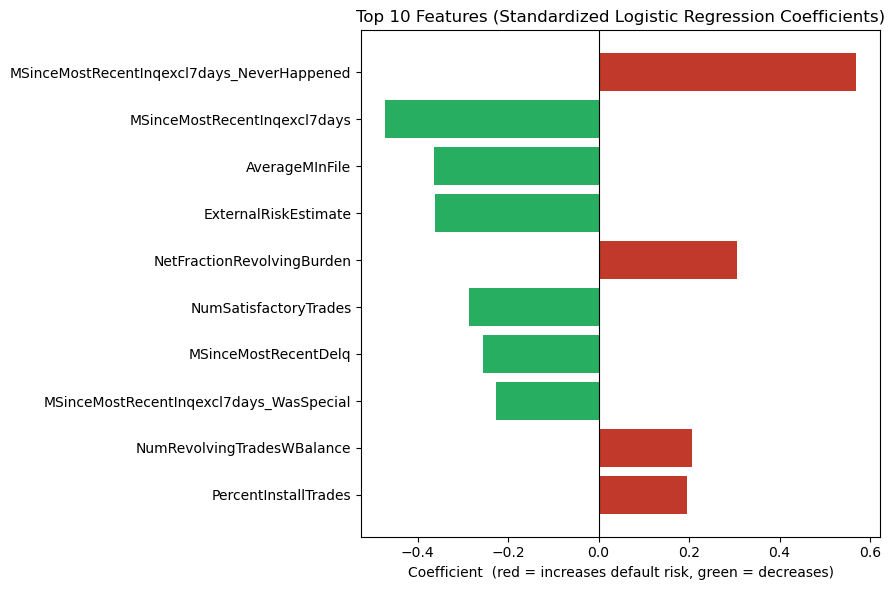

In [60]:
top10 = coef.head(10).iloc[::-1]  # reversed for horizontal bar order

plt.figure(figsize=(9, 6))
colors = ["#c0392b" if c > 0 else "#27ae60" for c in top10["Coefficient"]]
plt.barh(top10["Feature"], top10["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 10 Features (Standardized Logistic Regression Coefficients)")
plt.xlabel("Coefficient  (red = increases default risk, green = decreases)")
plt.tight_layout()
plt.savefig("../images/logistic_features.png", dpi=300, bbox_inches="tight")
plt.show()

### Results Interpretation

With standardized coefficients, the ranking reflects each feature's actual contribution rather than its measurement scale — and the picture changes markedly from the unscaled version:

- **`ExternalRiskEstimate` rises from 10th to among the top base features (coefficient −0.361)**: higher bureau risk scores strongly *reduce* estimated default risk, as expected (it behaves like a credit score — higher is better). Its previous last-place ranking was purely a units artifact.
- The former "dominance" of the inquiry counts disappears: `NumInqLast6M` falls to a modest +0.141 (more recent inquiries → higher risk, but far from the strongest signal).
- The strongest protective signals are **credit-file depth and clean history**: `AverageMInFile` (−0.363), `NumSatisfactoryTrades` (−0.287), `MSinceMostRecentDelq` (−0.255, longer since last delinquency → lower risk), and `PercentTradesNeverDelq` (−0.177).
- The strongest risk-increasing signals are **revolving-credit pressure**: `NetFractionRevolvingBurden` (+0.306), `NumRevolvingTradesWBalance` (+0.206), and `NumBank2NatlTradesWHighUtilization` (+0.172).

One technical note: the engineered indicator columns must be read **jointly** with their base features. `MSinceMostRecentInqexcl7days_NeverHappened` (+0.570) appears at the top, but for flagged applicants the base column is simultaneously filled with the training-set maximum, which pulls strongly in the opposite direction through its −0.472 coefficient; the pair together encodes the "no recent inquiry on record" group, and neither coefficient should be interpreted in isolation.

### Business Implications

The signed coefficients translate directly into lending policy language: default risk rises with **revolving-credit pressure** (high revolving burden and utilization) and **recent credit-seeking behaviour**, and falls with **file depth and a clean delinquency history** (long average file age, many satisfactory trades, high external risk score, longer time since any delinquency). These align with established credit-risk practice, and — because they come from the deployed model's own standardized coefficients rather than a post-hoc approximation — they can serve as defensible adverse-action reasoning in a regulated setting.

# 7. Probability Calibration and Decision Thresholds

The application does two things a bare classifier does not: it **displays a probability of default** to the user, and it maps that probability to **Approve / Review / Decline** recommendations. Both deserve explicit treatment.

## 7.1 Probability Calibration

A displayed "28.7% probability of default" should mean that, among applicants with that score, roughly 28.7% actually default. Isotonic calibration adjusts the model's raw scores toward this property; the Brier score (lower is better) measures the quality of the probabilities themselves.

Brier score (raw)        : 0.1786
Brier score (calibrated) : 0.1783


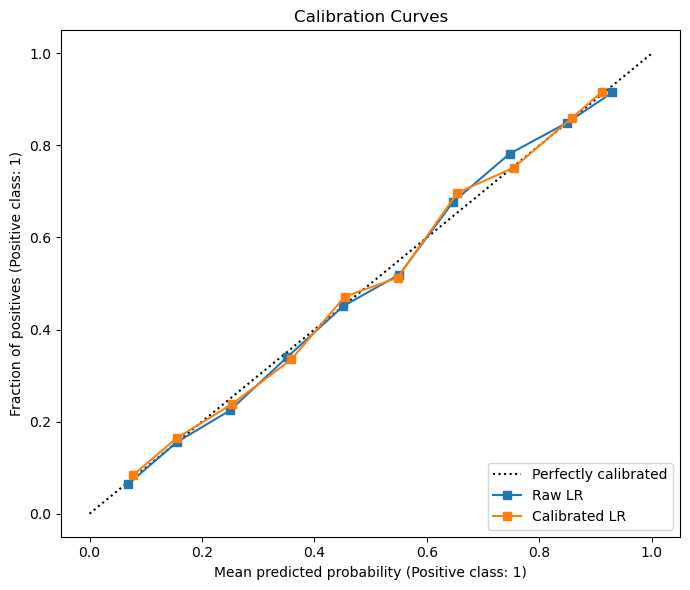

In [61]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss

calibrated_lr = CalibratedClassifierCV(pipe_lr, method="isotonic", cv=5)
calibrated_lr.fit(X_train, y_train)

prob_raw = pipe_lr.predict_proba(X_test)[:, 1]
prob_cal = calibrated_lr.predict_proba(X_test)[:, 1]

print(f"Brier score (raw)        : {brier_score_loss(y_test, prob_raw):.4f}")
print(f"Brier score (calibrated) : {brier_score_loss(y_test, prob_cal):.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(y_test, prob_raw, n_bins=10, name="Raw LR", ax=ax)
CalibrationDisplay.from_predictions(y_test, prob_cal, n_bins=10, name="Calibrated LR", ax=ax)
plt.title("Calibration Curves")
plt.tight_layout()
plt.savefig("../images/calibration_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### Results Interpretation

The Brier score barely moves (0.1786 → 0.1783) and both curves track the diagonal closely: the raw logistic regression probabilities were already well calibrated — a known strength of logistic regression, whose log-loss training objective directly rewards calibrated probabilities. Isotonic calibration therefore serves here as **validation** rather than correction, confirming that the probability displayed in the application can be read at face value.

## 7.2 Cost-Based Threshold Selection

The two error types have very different business costs: approving a future defaulter (false negative from the lender's screening perspective) typically costs far more than declining a good applicant (lost margin). The default 0.5 threshold ignores this asymmetry.

Assuming an illustrative cost ratio — a missed defaulter costs **5×** as much as a wrongly declined good applicant — the expected cost is computed across all thresholds. The 5:1 ratio is an assumption for demonstration; in practice it comes from the lender's loss-given-default and margin data, and the optimal threshold shifts with it.

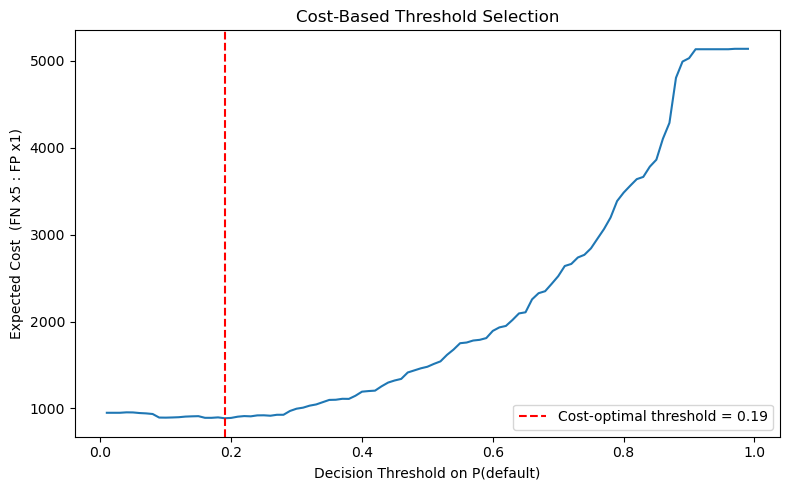

Cost-optimal single threshold: 0.19


In [62]:
y_prob = calibrated_lr.predict_proba(X_test)[:, 1]   # calibrated P(default)

C_FN, C_FP = 5, 1   # cost of missing a defaulter vs declining a good applicant

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred_default = (y_prob >= t).astype(int)              # 1 = flag as risky
    fn = ((pred_default == 0) & (y_test == 1)).sum()      # defaulter approved
    fp = ((pred_default == 1) & (y_test == 0)).sum()      # good applicant declined
    costs.append(C_FN * fn + C_FP * fp)

costs = np.array(costs)
best_t = thresholds[costs.argmin()]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs)
plt.axvline(best_t, ls="--", c="red", label=f"Cost-optimal threshold = {best_t:.2f}")
plt.xlabel("Decision Threshold on P(default)")
plt.ylabel(f"Expected Cost  (FN x{C_FN} : FP x{C_FP})")
plt.title("Cost-Based Threshold Selection")
plt.legend()
plt.tight_layout()
plt.savefig("../images/threshold_cost.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Cost-optimal single threshold: {best_t:.2f}")

### Results Interpretation

Under the illustrative 5:1 cost ratio, the expected-cost curve is minimized at a threshold of **0.19** — far below the conventional 0.5. This is the expected behaviour when missing a defaulter is five times as costly as declining a good applicant: the lender should be willing to decline many borderline cases to avoid a single costly default. The curve is flat near its minimum, so any threshold in roughly the 0.10–0.25 range yields similar expected cost — which motivates using a band rather than a single cut-off in the next section.

## 7.3 Three-Tier Recommendation Policy (Approve / Review / Decline)

As a decision-support system, the application does not force a binary call. Predictions near the cost-optimal threshold are the genuinely ambiguous cases — exactly where a human underwriter adds the most value. A band around the optimal threshold defines the **Review** tier:

- `P(default) < t_low` → **Approve**
- `t_low ≤ P(default) < t_high` → **Review** (route to human underwriter)
- `P(default) ≥ t_high` → **Decline**

The band width trades off automation rate against risk; the cell below reports, for the chosen tiers, the share of applications in each tier and the observed default rate within each — the numbers to quote in the README.

In [63]:
BAND = 0.10                       # half-width of the Review band around best_t
t_low = round(max(best_t - BAND, 0.01), 2)    # clipped so bins stay valid
t_high = round(min(best_t + BAND, 0.99), 2)

tier = pd.cut(
    y_prob,
    bins=[0, t_low, t_high, 1.0],
    labels=["Approve", "Review", "Decline"],
    include_lowest=True,
)

summary = pd.DataFrame({
    "Share of applications": pd.Series(tier).value_counts(normalize=True).round(3),
    "Observed default rate": pd.Series(y_test.values).groupby(tier, observed=False).mean().round(3),
})

print(f"Tiers: Approve < {t_low:.2f} <= Review < {t_high:.2f} <= Decline")
summary

Tiers: Approve < 0.09 <= Review < 0.29 <= Decline


,Share of applications,Observed default rate
Approve,0.054,0.084
Review,0.205,0.198
Decline,0.741,0.641


### Results Interpretation

With tiers at **Approve < 0.09 ≤ Review < 0.29 ≤ Decline**, the policy separates risk cleanly: the Approve tier has an observed default rate of only **8.4%** versus the dataset base rate of ~52% — a six-fold risk reduction — while the Decline tier concentrates genuinely high-risk applicants (**64.1%** observed default rate). The Review tier (20.5% of applications, 19.8% default rate) captures exactly the ambiguous middle where human judgment adds the most value.

Note that the tier shares (5.4% / 20.5% / 74.1%) reflect this research dataset's unusually high base default rate; a real through-the-door applicant population has a far lower base rate, and the same calibrated model and thresholds would route a much larger share to Approve. In production, tier boundaries would be set from the lender's actual loss-given-default and margin data rather than the illustrative 5:1 ratio.

## 7.4 Save the Deployment Artifact

The **calibrated pipeline** (special-value handling → imputation → scaling → logistic regression → isotonic calibration) is saved as a single object, together with the tier thresholds. The Streamlit app loads this one file and calls `predict_proba` on raw inputs — no preprocessing code is duplicated on the app side.

> Note: loading this pickle requires `SpecialValueTransformer` to be importable, i.e. the app must also `from src.preprocessing import SpecialValueTransformer` before `joblib.load`.

In [64]:
import joblib

artifact = {
    "pipeline": calibrated_lr,
    "feature_columns": list(X_train.columns),
    "thresholds": {"approve_below": t_low, "decline_from": t_high},
    "positive_class": "Bad (default) = 1",
}

joblib.dump(artifact, "../models/heloc_pipeline.pkl")
print("Saved ../models/heloc_pipeline.pkl")

Saved ../models/heloc_pipeline.pkl


# 8. Conclusion

This project developed a machine learning **decision-support system** — not an automated approval engine — for HELOC credit risk: the model provides calibrated default probabilities and Approve / Review / Decline recommendation tiers to assist human underwriters.

Four classifiers were compared with both a hold-out test set and 5-fold cross-validation, using Precision, Recall, F1, and ROC-AUC (positive class = default). Preprocessing encodes the FICO special values according to their business meaning, and the entire preprocessing-to-prediction chain is a single saved pipeline shared with the deployed application.

In [66]:
comparison = pd.DataFrame(results).T.round(4)
comparison.sort_values(by="ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7362,0.7380,0.7646,0.7511,0.8081
XGBoost (tuned),0.7362,0.7363,0.7685,0.7520,0.8048
Random Forest,0.7367,0.7356,0.7714,0.7531,0.8017
XGBoost,0.7195,0.7182,0.7588,0.7379,0.7803
Decision Tree,0.6390,0.6516,0.6586,0.6551,0.6382


### Findings

Across both evaluation protocols, Logistic Regression was the strongest and most stable model: hold-out ROC-AUC of **0.808** and 5-fold CV ROC-AUC of **0.8041 ± 0.0094**, ahead of Random Forest (0.7911 ± 0.0125) and statistically tied with a tuned XGBoost (0.8033). The single Decision Tree (0.6292 ± 0.0102) confirmed the value of ensembling and regularization. At the default 0.5 threshold the deployed model catches ~76% of true defaulters; the cost-based analysis in Section 7 replaces this arbitrary threshold with business-driven Approve / Review / Decline tiers (Approve < 0.09 ≤ Review < 0.29 ≤ Decline), under which the Approve tier shows an observed default rate of just 8.4% against a ~52% dataset base rate.

### Business Implications

The strongest risk signals identified by the standardized coefficients — revolving-credit pressure, recent credit-seeking behaviour, and thin or blemished credit files — align with established credit-risk practice. Because the deployed model is intrinsically interpretable, each recommendation can be traced to specific applicant characteristics, supporting regulator-friendly adverse-action explanations. Logistic Regression coefficients were chosen over post-hoc methods because the project prioritizes transparent explanations of the deployed model itself; SHAP analysis of the tree ensembles remains future work for comparison.

### Limitations and Future Work

- The 5:1 cost ratio in the threshold analysis is illustrative; production thresholds should be derived from actual loss-given-default and margin data.
- SHAP-based interpretation of the tuned XGBoost model would allow a direct interpretability comparison with the linear model.
- Fairness auditing (e.g. performance parity across applicant segments) is an important next step for any credit model, though this dataset contains no protected attributes.
- Monitoring for data drift between bureau snapshots would be required in production.